<a href="https://colab.research.google.com/github/jerrinojacob/Data-Science-Portfolio/blob/main/project_02/Housing_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Housing Price Prediction


## Problem Definition

This project involves developing a machine learning model to extract and rank the most influential predictor variables that demonstrate the strongest correlation with elevated housing sale prices and reduced time-to-sale metrics.


The target variable, SalePrice, is a continuous numeric data on a real-valued scale, defining this as a supervised regression task where the model must optimize for continuous prediction accuracy using appropriate regression-specific functions and evaluation metrics.

###Given Files and Data

[Housing Data Dictionary](https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Housing%20-%20Data%20Documentation.pdf)

[Housing Data File](https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv)


##Data Collection

###Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import statsmodels.api as sm




###Extracting data from given URL stored in the AWS S3 Bucket into a dataframe


In [2]:
# Initializing the url to a variable
url='https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'

# Extracting the content of the csv file into a dataframe
house_df = pd.read_csv(url)

###HTTP response header
- describes the details of the csv especially the size of the file
  - file size ~ 860KB (880,420 bytes)
  - file type: csv
  - file last modified: 10/06/2023


In [3]:
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: F+8cCf1XxTYMgiGeoj4PfFyFXakQUW8dZ/at+mpoxEb4uM3VheZuGNZA0HQit4p0xTbGpLgghtH5jGLXZfQleR8js/WEqpZJ
x-amz-request-id: PPCQP09NS7N5WWPD
Date: Wed, 15 Oct 2025 22:25:02 GMT
Last-Modified: Fri, 06 Oct 2023 04:00:27 GMT
ETag: "76e84c9ee7f6fd4d51276697f81e76e1"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 880420
Server: AmazonS3



##Data Cleaning

###Understanding the data structure of the dataset
* Using
  - shape
  - size
  - printing top 5 records
  - printing bottom 10 records
  - info
  - stats



In [4]:
print(f"Data Details - Dataset:\n------------------------------------------------\nDimensions(/Shape): \t{house_df.shape[0]:,} x {house_df.shape[1]:,}\n")
print(f"Total Elements(/Size): \t{house_df.size:,}\n\nSample Dataset:\n------------------------------------------------\nTop Five Events\n-----------------")
house_df.head()

Data Details - Dataset:
------------------------------------------------
Dimensions(/Shape): 	2,637 x 81

Total Elements(/Size): 	213,597

Sample Dataset:
------------------------------------------------
Top Five Events
-----------------


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


In [5]:
#Tail end of the dataframe
house_df.tail(10)

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2627,907135040,20,RL,112.0,10859,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,145000
2628,907280040,60,RL,75.0,9375,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,240000
2629,909252170,70,RL,53.0,6720,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2007,CWD,Normal,141500
2630,534401130,80,RL,82.0,9020,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,5,2008,WD,Normal,174900
2631,535457020,20,RL,80.0,8000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,11,2007,WD,Normal,156500
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000
2636,528292060,60,RL,41.0,12460,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,225000


In [6]:
# Summary of the dataframe
house_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

In [7]:
numeric_int       = len(house_df.select_dtypes(include=['int64']).columns)
numeric_float     = len(house_df.select_dtypes(include=['float64']).columns)
categorical_dtype = len(house_df.select_dtypes(include=['object']).columns)
print(f'Out of the {house_df.shape[1]} features/columns, the following are the data types listed:\n- integer: {numeric_int},\n- float: {numeric_float}, and\n- object: {categorical_dtype}')

Out of the 81 features/columns, the following are the data types listed:
- integer: 27,
- float: 11, and
- object: 43


In [8]:
#Stats of the Dataset
house_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PID,2637.0,7.141301e+08,1.887527e+08,526301100.0,5.284770e+08,535453040.0,9.071870e+08,1.007100e+09
MS SubClass,2637.0,5.734926e+01,4.249909e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2188.0,6.916682e+01,2.335678e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2637.0,1.004469e+04,6.742550e+03,1300.0,7.436000e+03,9450.0,1.152600e+04,1.646600e+05
Overall Qual,2637.0,6.097459e+00,1.411522e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2637.0,5.569966e+00,1.118262e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2637.0,1.971289e+03,3.030699e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2637.0,1.984203e+03,2.091308e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2614.0,1.018879e+02,1.795782e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03
BsmtFin SF 1,2636.0,4.384412e+02,4.496023e+02,0.0,0.000000e+00,368.0,7.320000e+02,5.644000e+03


###PID - identifier column
  - contains all values unique
  - is a unique identifier to the dataset
  - needs to be dropped from modeling

In [9]:
print(f"Existing Nulls in PID: {int(house_df["PID"].isna().sum())}")
print(f"Unique Values in PID: {house_df["PID"].nunique()}")
print(f"Data Type in PID: {type(house_df['PID'].dtype.itemsize)}")

Existing Nulls in PID: 0
Unique Values in PID: 2637
Data Type in PID: <class 'int'>


###SalePrice - Target column
  - based on the problem, SalePrice is the Target
  - it is a integer
  - since there are no nulls it requires no imputation.

In [10]:
print(f"Existing Nulls in SalePrice: {int(house_df["SalePrice"].isna().sum())}")
print(f"Unique Values in SalePrice: {house_df["SalePrice"].nunique()}")
print(f"Data Type in SalePrice: {type(house_df['SalePrice'].dtype.itemsize)}")

Existing Nulls in SalePrice: 0
Unique Values in SalePrice: 983
Data Type in SalePrice: <class 'int'>


###Feature Columns


###Identifying the Null columns

In [11]:
#This method is to set all values visible on this standard output
# pd.set_option('display.max_rows', None)

* Checking List of Features with NULLS and their count

In [12]:
house_df.isna().sum()[
    house_df.isna().sum() > 0
  ].sort_values(ascending=False)

,0
Pool QC,2626
Misc Feature,2541
Alley,2457
Fence,2109
Mas Vnr Type,1607
Fireplace Qu,1284
Lot Frontage,449
Garage Cond,147
Garage Yr Blt,147
Garage Finish,147


In [13]:
#Checking for total count of features with nulls
house_df.isna().sum()[
    house_df.isna().sum() > 0
  ].sort_values(ascending=False).count()

np.int64(26)

* There are 26 features with nulls that needs to be handled
* Creating a heatmap to identify the nulls visually

<Axes: >

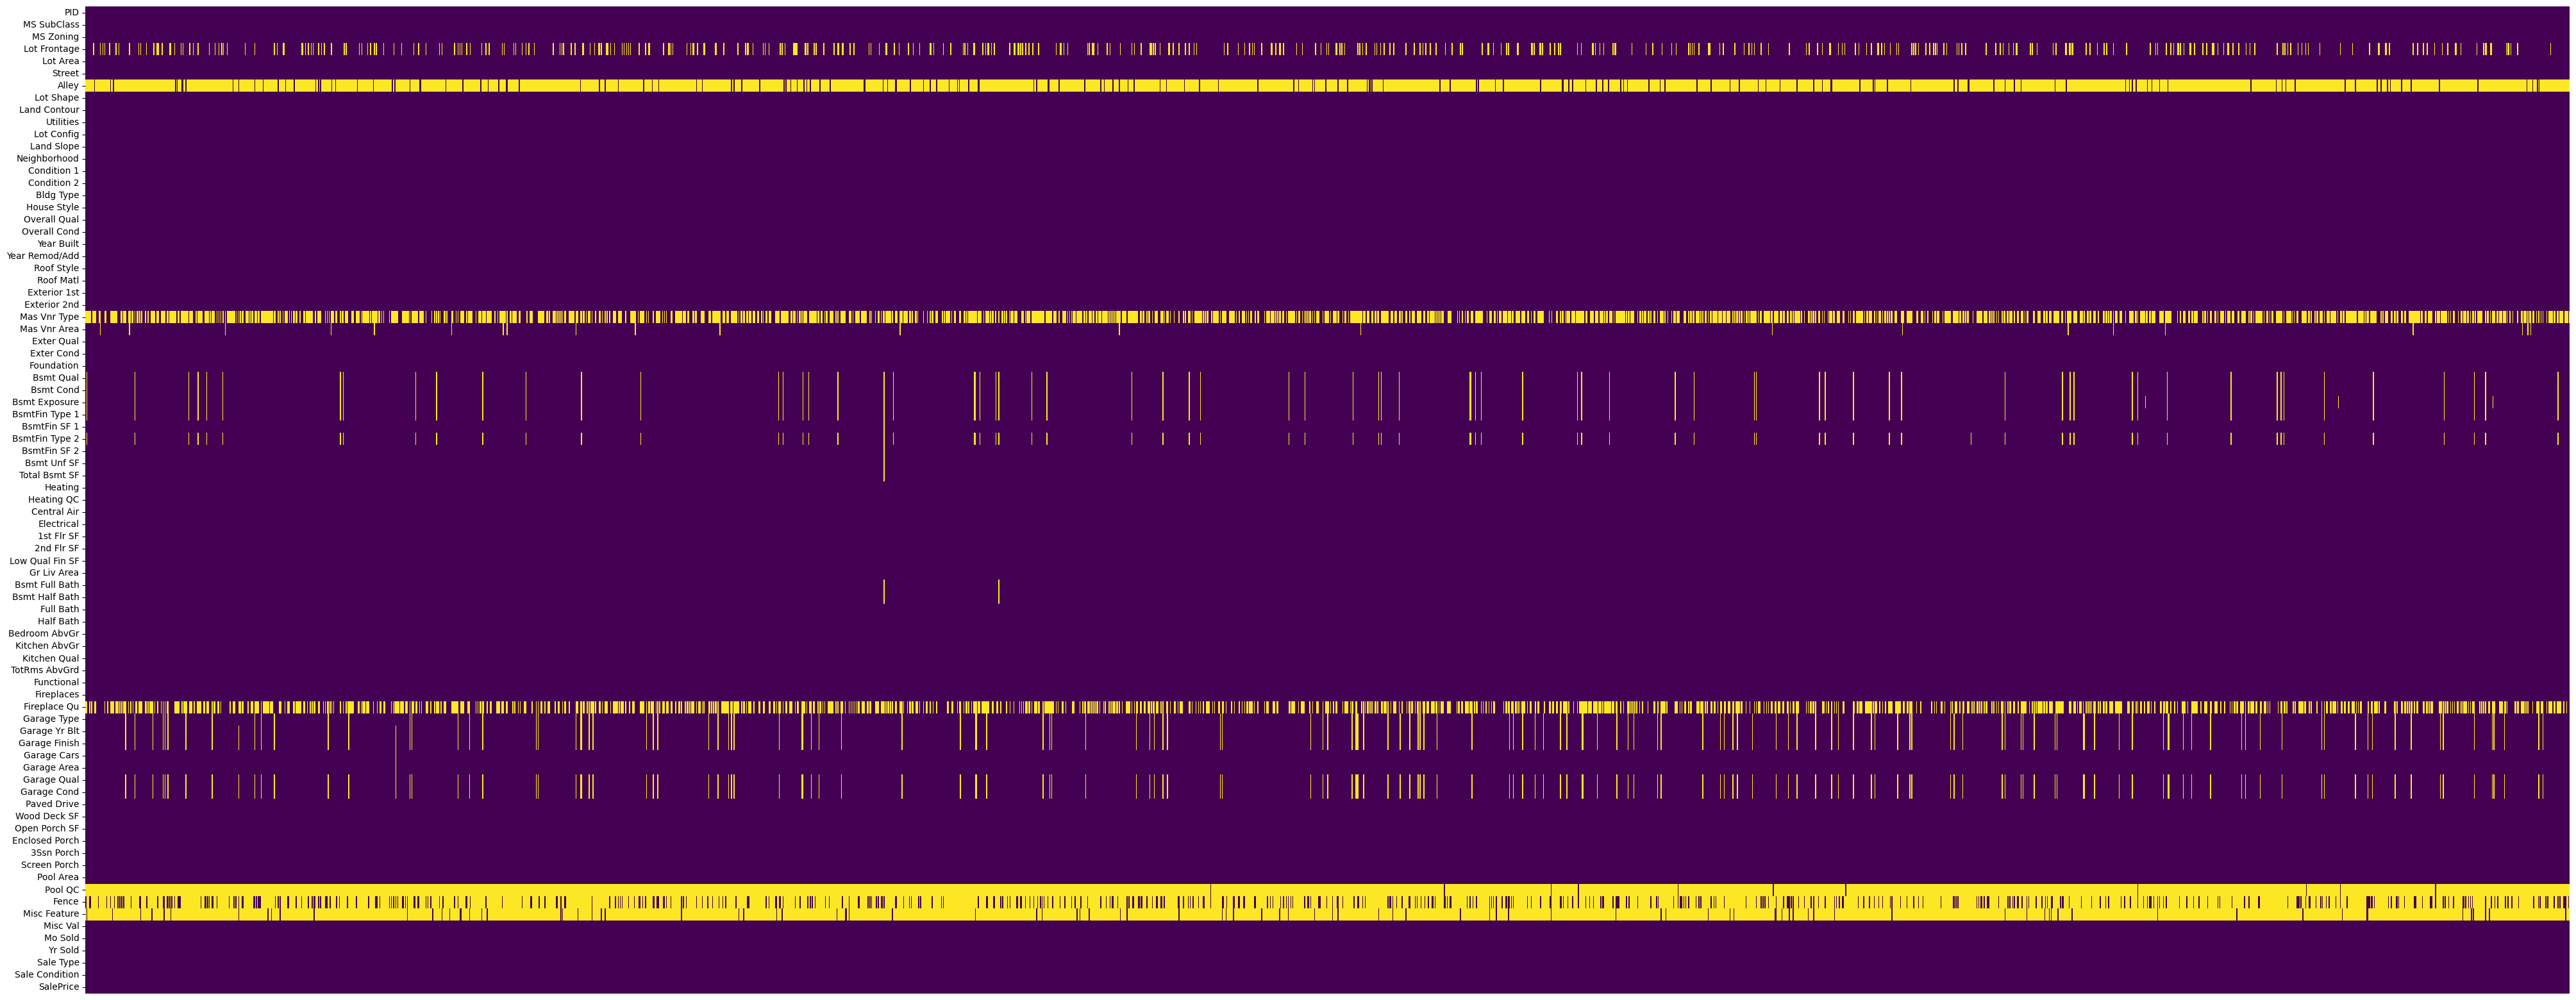

In [14]:
#Heatmap is great to determine the nulls visually
plt.figure(figsize=(50,20))
sns.heatmap(house_df.isnull().transpose(), xticklabels=False, cbar=False, cmap='viridis')

###Observations on null features
* There are #26 features that have nulls
* There are 2,637 observations in this dataset.
* We need not consider any feature that has half or more of the observations with null values.

In [15]:
# Determining the half of the total observations
half_count_of_rows=len(house_df)/2
half_count_of_rows

1318.5

* 5 columns have more than 50% of the total rows

In [16]:
# house_df.count().sort_values(ascending=False)

In [17]:
#Creating a list to hold the 5 features and 1 categorical column to drop
cols_to_drop = house_df.columns[house_df.count()<=len(house_df)/2]
cols_to_drop = cols_to_drop.append(pd.Index([house_df.columns[0]]))
cols_to_drop

Index(['Alley', 'Mas Vnr Type', 'Pool QC', 'Fence', 'Misc Feature', 'PID'], dtype='object')

###Dropping High Null Columns

In [18]:
#Backup#01: Dropping High Null Features
house_df_bkp01= house_df.copy()

In [19]:
#restore
house_df=house_df_bkp01.copy()

In [20]:
#drop the cols
house_nulls_dropped_df=house_df.drop(columns=cols_to_drop, axis=1, inplace=True)

In [21]:
#Identify Numerical & Categorical Features after dropping

#Numerical Features
numerical_df = house_df.select_dtypes(include=np.number)
numerical_list = numerical_df.columns.tolist()
numeric_dtype     = len(numerical_list)

#Categorical Features
categorical_df = house_df.select_dtypes(exclude=np.number)
categorical_list = categorical_df.columns.tolist()
categorical_dtype = len(categorical_list)

print(f'Out of the {house_df.shape[1]} features/columns, the following are the data types listed:\n\n- Numerical[{numeric_dtype}]: {numerical_list},\n\n- Categorical[{categorical_dtype}]: {categorical_list}\n\n')


Out of the 75 features/columns, the following are the data types listed:

- Numerical[37]: ['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice'],

- Categorical[38]: ['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Ty

###Numerical Features Analysis

In [22]:
#List of Numerical features with null values
numerical_df.isna().sum()[
    numerical_df.isna().sum() >0
].sort_values(ascending=False)

,0
Lot Frontage,449
Garage Yr Blt,147
Mas Vnr Area,23
Bsmt Half Bath,2
Bsmt Full Bath,2
BsmtFin SF 1,1
BsmtFin SF 2,1
Total Bsmt SF,1
Bsmt Unf SF,1
Garage Cars,1


###Feature: 'Lot Frontage', 'Garage Yr Blt'
* 'Lot Frontage'  = 449 null values
* 'Garage Yr Blt' = 147 null values
* Dropping features

In [23]:
#Backup#02: Dropping High Null Features
house_df_bkp02 = numerical_df.copy()

In [24]:
#restore
house_num_df=house_df_bkp02.copy()

In [25]:
house_num_df.shape,house_num_df.size

((2637, 37), 97569)

In [26]:
#drop the cols
house_num_nulls_dropped_df=house_num_df.drop(['Lot Frontage','Garage Yr Blt'], axis=1, inplace=True)

In [27]:
house_num_df.shape,house_num_df.size

((2637, 35), 92295)

In [28]:
house_num_df.head()

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,20,14299,4,3,1964,1964,0.0,513.0,144.0,348.0,...,0,0,0,0,0,0,0,7,2007,115400
1,90,10791,4,5,1967,1967,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,500,10,2006,90000
2,50,9000,6,6,1937,1950,0.0,0.0,0.0,780.0,...,0,162,0,0,126,0,0,12,2007,141000
3,60,7379,8,5,2000,2000,0.0,484.0,0.0,491.0,...,280,184,0,0,0,0,0,4,2010,254000
4,70,7200,7,9,1936,2007,0.0,350.0,210.0,0.0,...,256,0,0,0,0,0,0,4,2009,155000


<Axes: >

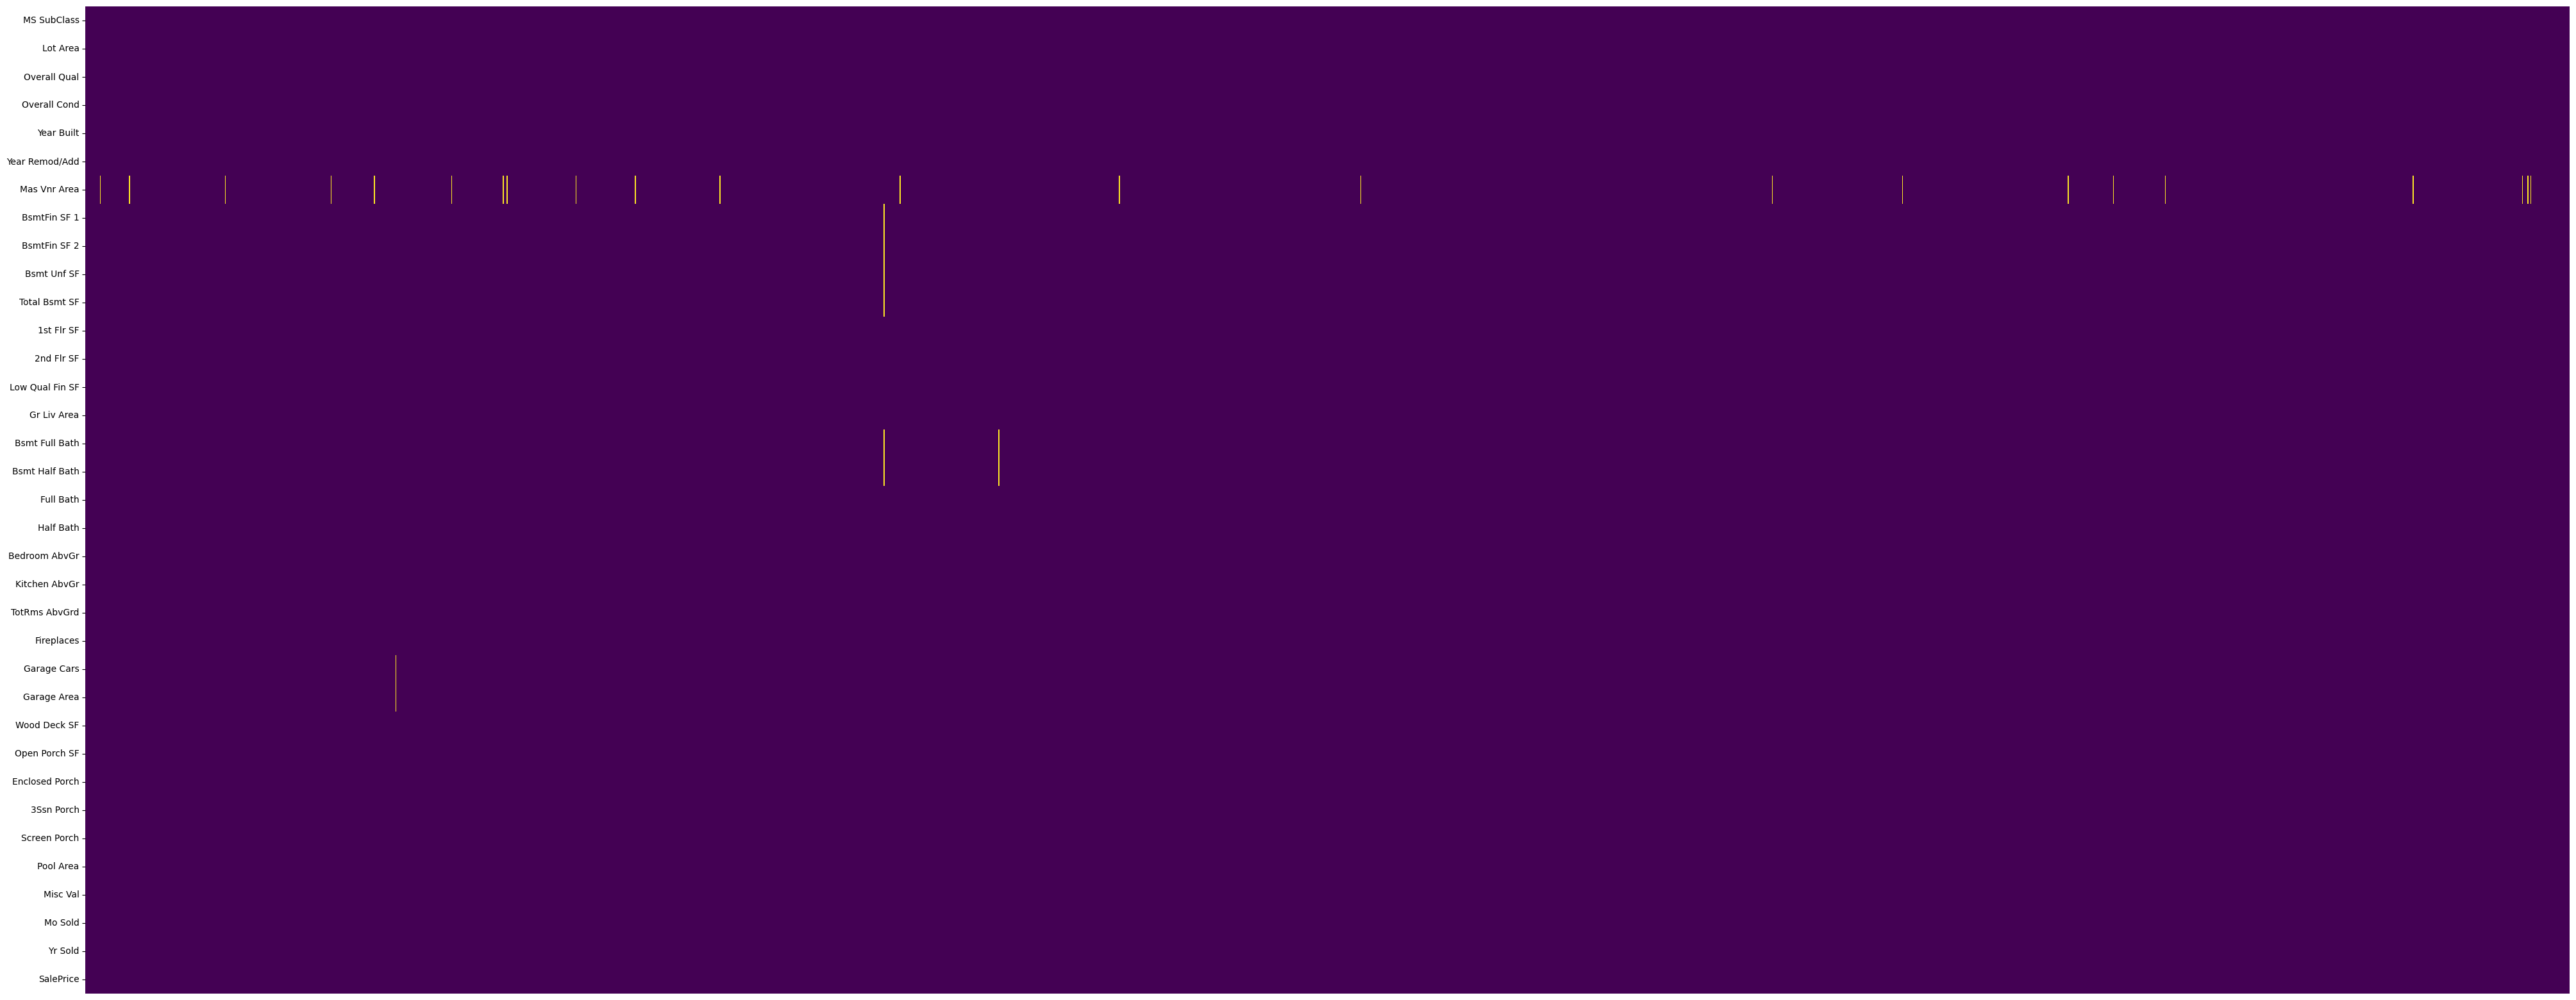

In [29]:
#Heatmap is great to determine the nulls visually
plt.figure(figsize=(50,20))
sns.heatmap(house_num_df.isnull().transpose(), xticklabels=False, cbar=False, cmap='viridis')

In [30]:
#List of remaining Numerical features with null values
num_feature_nulls=house_num_df.isna().sum()[
    house_num_df.isna().sum() >0
].sort_values(ascending=False)
num_feature_nulls

,0
Mas Vnr Area,23
Bsmt Half Bath,2
Bsmt Full Bath,2
BsmtFin SF 1,1
BsmtFin SF 2,1
Total Bsmt SF,1
Bsmt Unf SF,1
Garage Cars,1
Garage Area,1


In [31]:
num_feature_desc=house_num_df[num_feature_nulls.index.tolist()].describe()
num_feature_desc

,Mas Vnr Area,Bsmt Half Bath,Bsmt Full Bath,BsmtFin SF 1,BsmtFin SF 2,Total Bsmt SF,Bsmt Unf SF,Garage Cars,Garage Area
count,2614.000000,2635.000000,2635.000000,2636.000000,2636.000000,2636.000000,2636.000000,2636.000000,2636.000000
mean,101.887911,0.058824,0.432258,438.441199,51.068665,1045.179059,555.669196,1.763278,470.968134
std,179.578232,0.240130,0.525239,449.602326,172.521803,429.686089,436.223188,0.760576,212.816905
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,792.000000,218.000000,1.000000,324.750000
50%,0.000000,0.000000,0.000000,368.000000,0.000000,988.000000,464.500000,2.000000,480.000000
75%,164.000000,0.000000,1.000000,732.000000,0.000000,1290.250000,797.250000,2.000000,576.000000
max,1600.000000,2.000000,3.000000,5644.000000,1526.000000,6110.000000,2336.000000,5.000000,1488.000000


###Imputing the missing values in the Numerical Features

In [32]:
#Backup03: Imputing Backup
house_num_bkp04=house_num_df.copy()

In [33]:
#Restore:
house_num_df=house_num_bkp04.copy()

In [34]:
# num_feature_desc=num_feature_desc.rename(index={'50%': 'median'})
for col in num_feature_desc:
  if(house_num_df[col].median()!=0):
    house_num_df[col].fillna(house_num_df[col].median(), inplace=True)
  else:
    house_num_df[col].fillna(house_num_df[col].mean(), inplace=True)

/tmp/ipython-input-3367918680.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  house_num_df[col].fillna(house_num_df[col].mean(), inplace=True)
/tmp/ipython-input-3367918680.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [35]:
num_feature_desc=house_num_df[num_feature_nulls.index.tolist()].describe()
num_feature_desc

,Mas Vnr Area,Bsmt Half Bath,Bsmt Full Bath,BsmtFin SF 1,BsmtFin SF 2,Total Bsmt SF,Bsmt Unf SF,Garage Cars,Garage Area
count,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000
mean,101.887911,0.058824,0.432258,438.414486,51.068665,1045.157376,555.634623,1.763367,470.971559
std,178.793075,0.240039,0.525040,449.519130,172.489076,429.606021,436.144051,0.760446,212.776606
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,792.000000,218.000000,1.000000,325.000000
50%,0.000000,0.000000,0.000000,368.000000,0.000000,988.000000,464.500000,2.000000,480.000000
75%,162.000000,0.000000,1.000000,732.000000,0.000000,1290.000000,797.000000,2.000000,576.000000
max,1600.000000,2.000000,3.000000,5644.000000,1526.000000,6110.000000,2336.000000,5.000000,1488.000000


<Axes: >

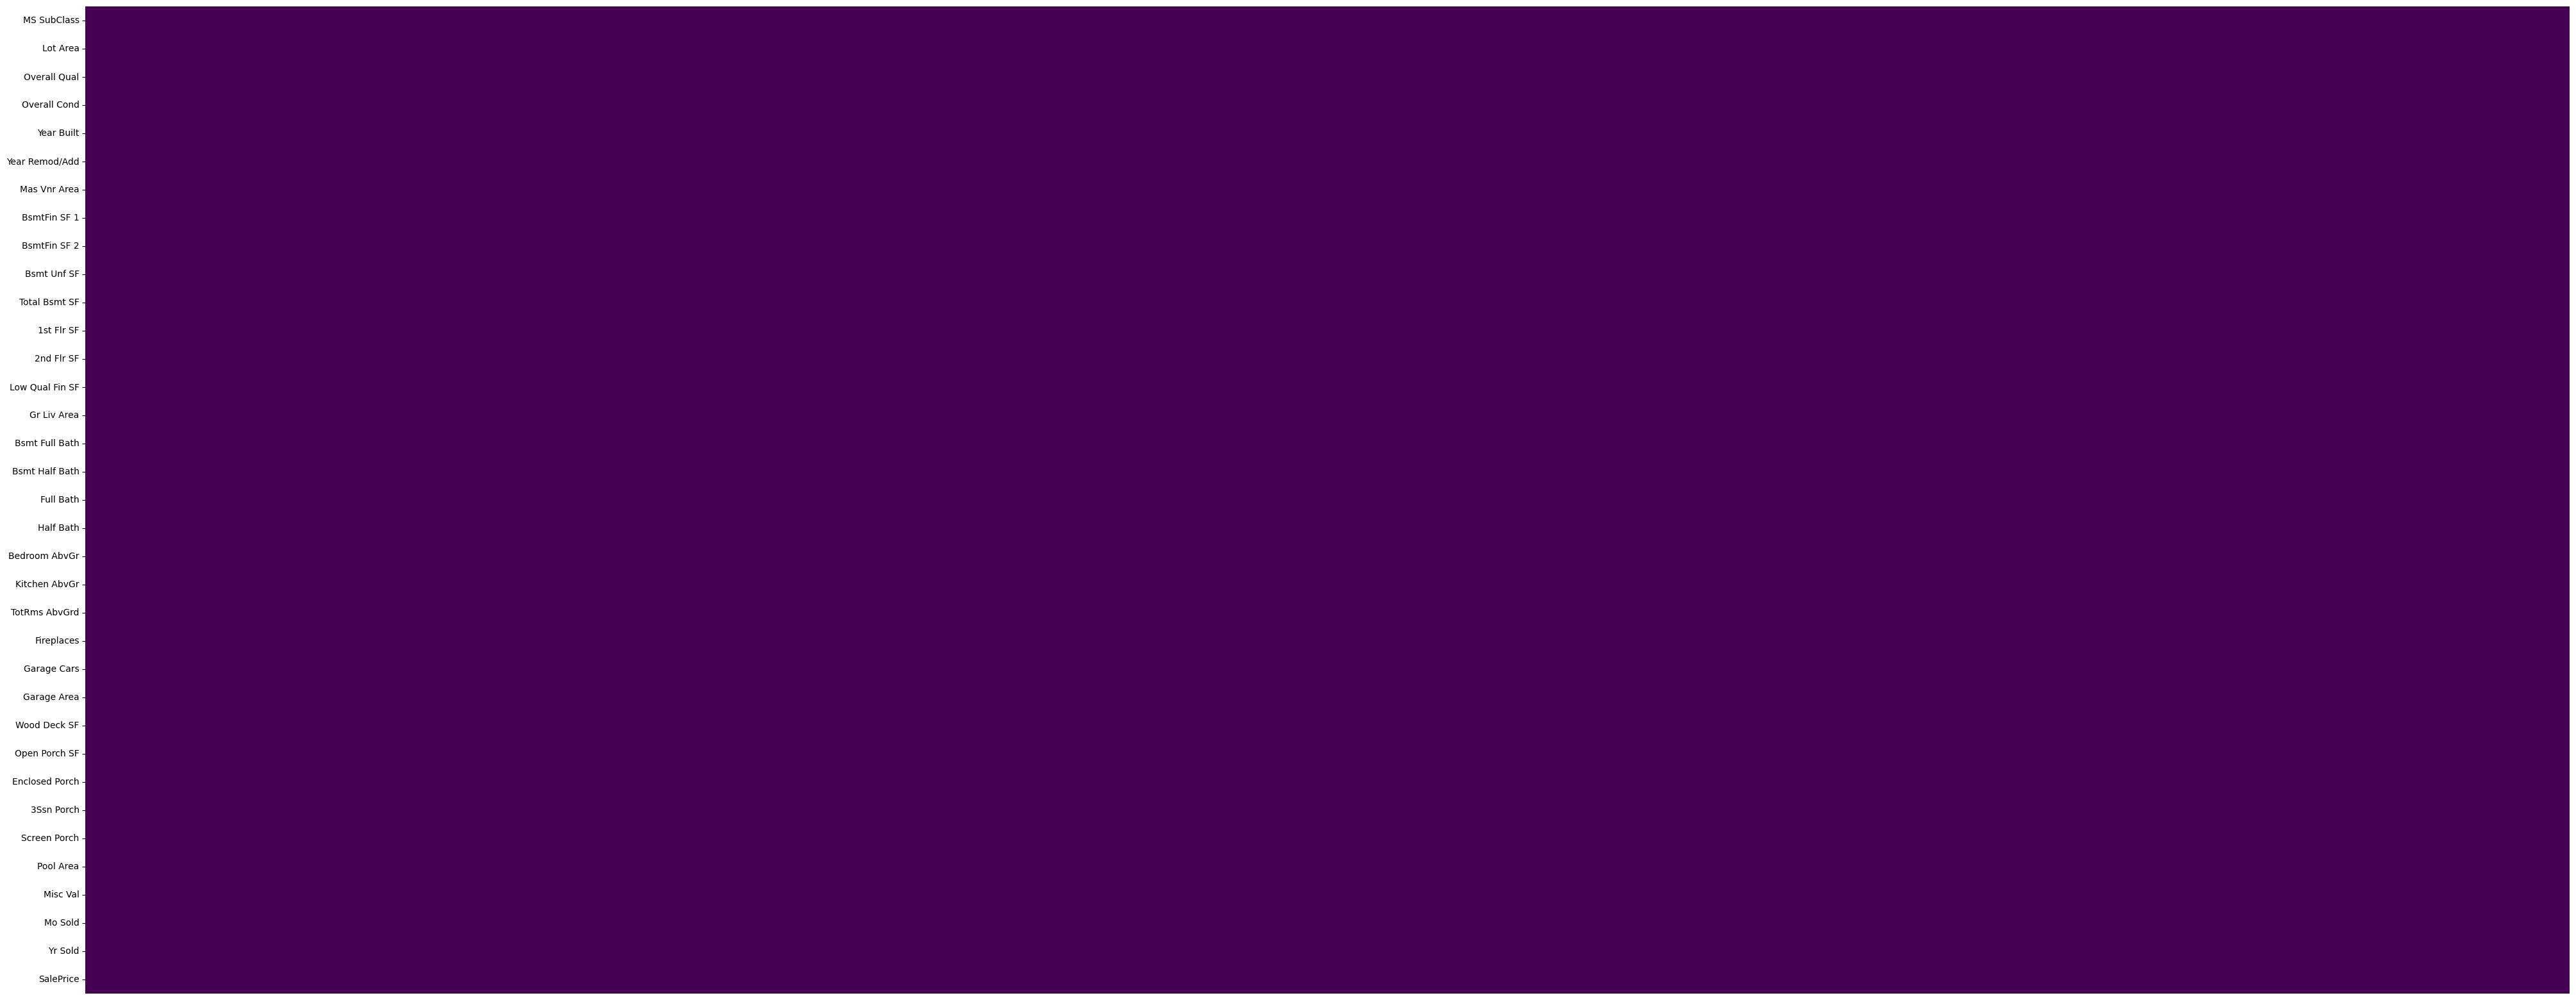

In [36]:
#Heatmap is great to determine the nulls visually
plt.figure(figsize=(50,20))
sns.heatmap(house_num_df.isnull().transpose(), xticklabels=False, cbar=False, cmap='viridis')

* Null Values in Numerical features are eliminated.

## Exploratory Data Analysis

###Correlations Matrix

* Creating the Correlation Matrix on the numerical features.

In [37]:
house_num_corr=house_num_df.corr()

* Heatmap on the correlations

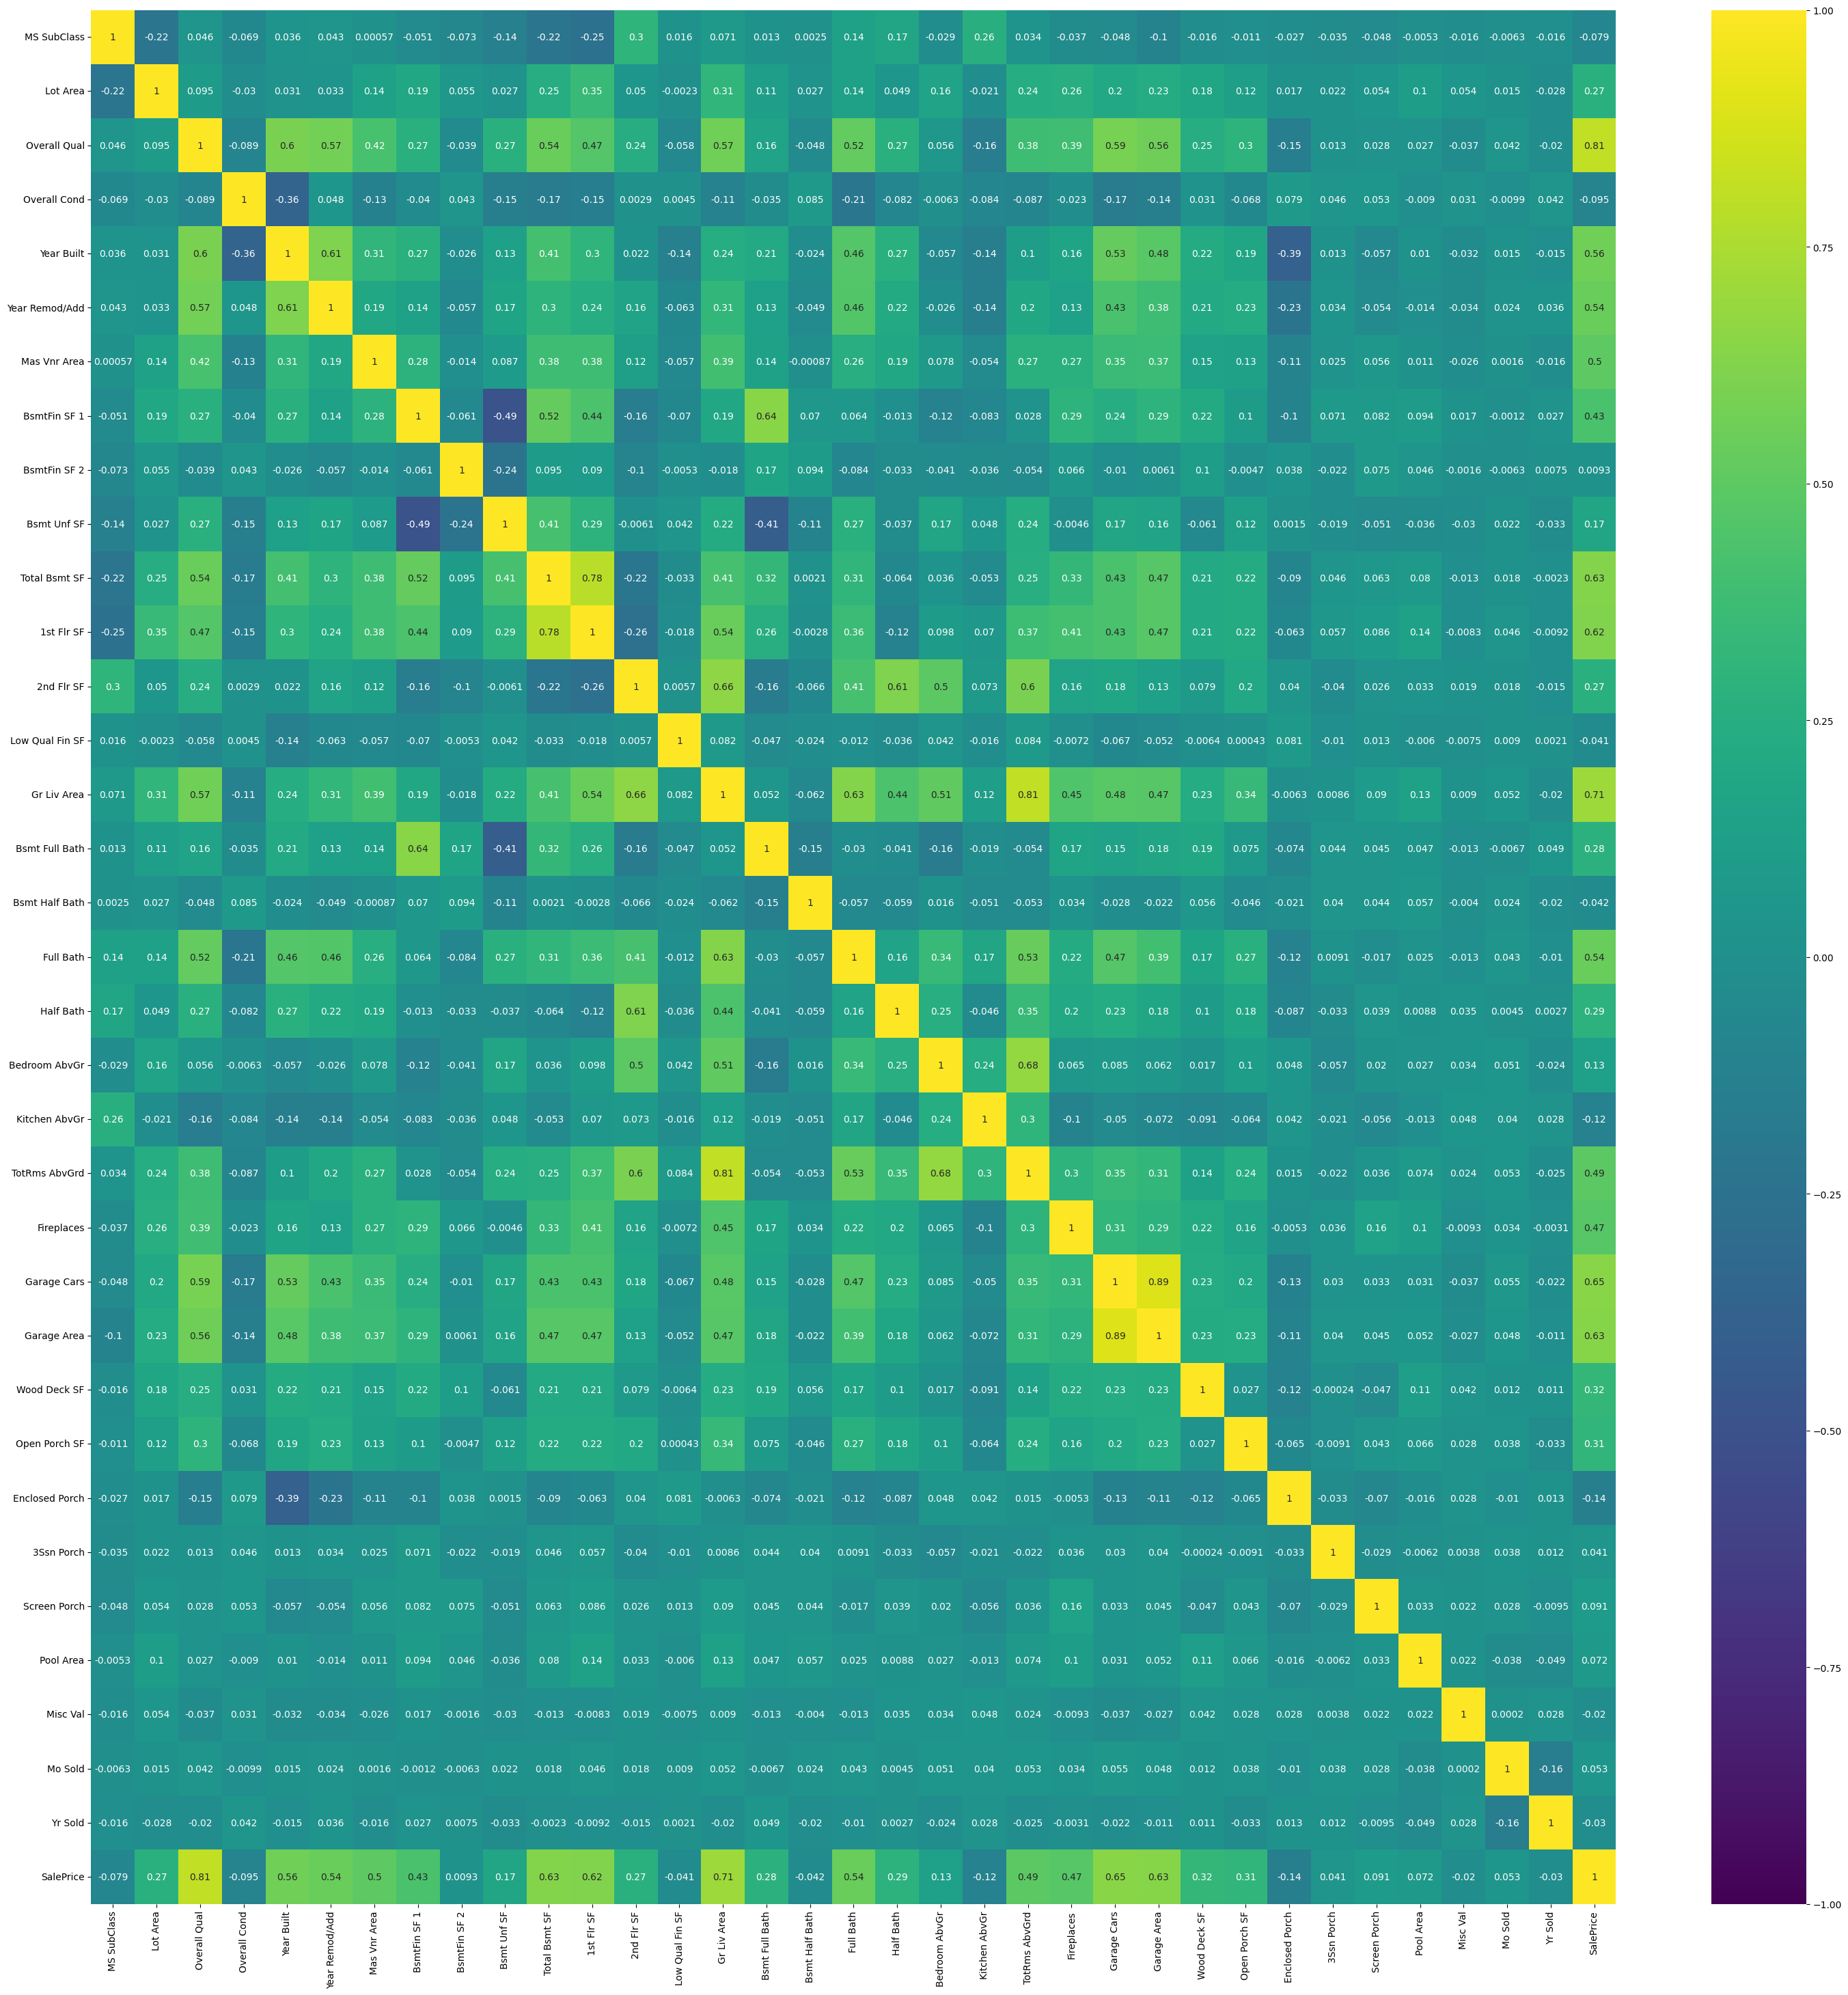

In [38]:
plt.figure(figsize=(36,36))
sns.heatmap(
    house_num_corr,
    cmap='viridis',
    annot = True,
    vmin = -1,
    vmax = 1
    );

* Histogram to show the correlation and the distribution

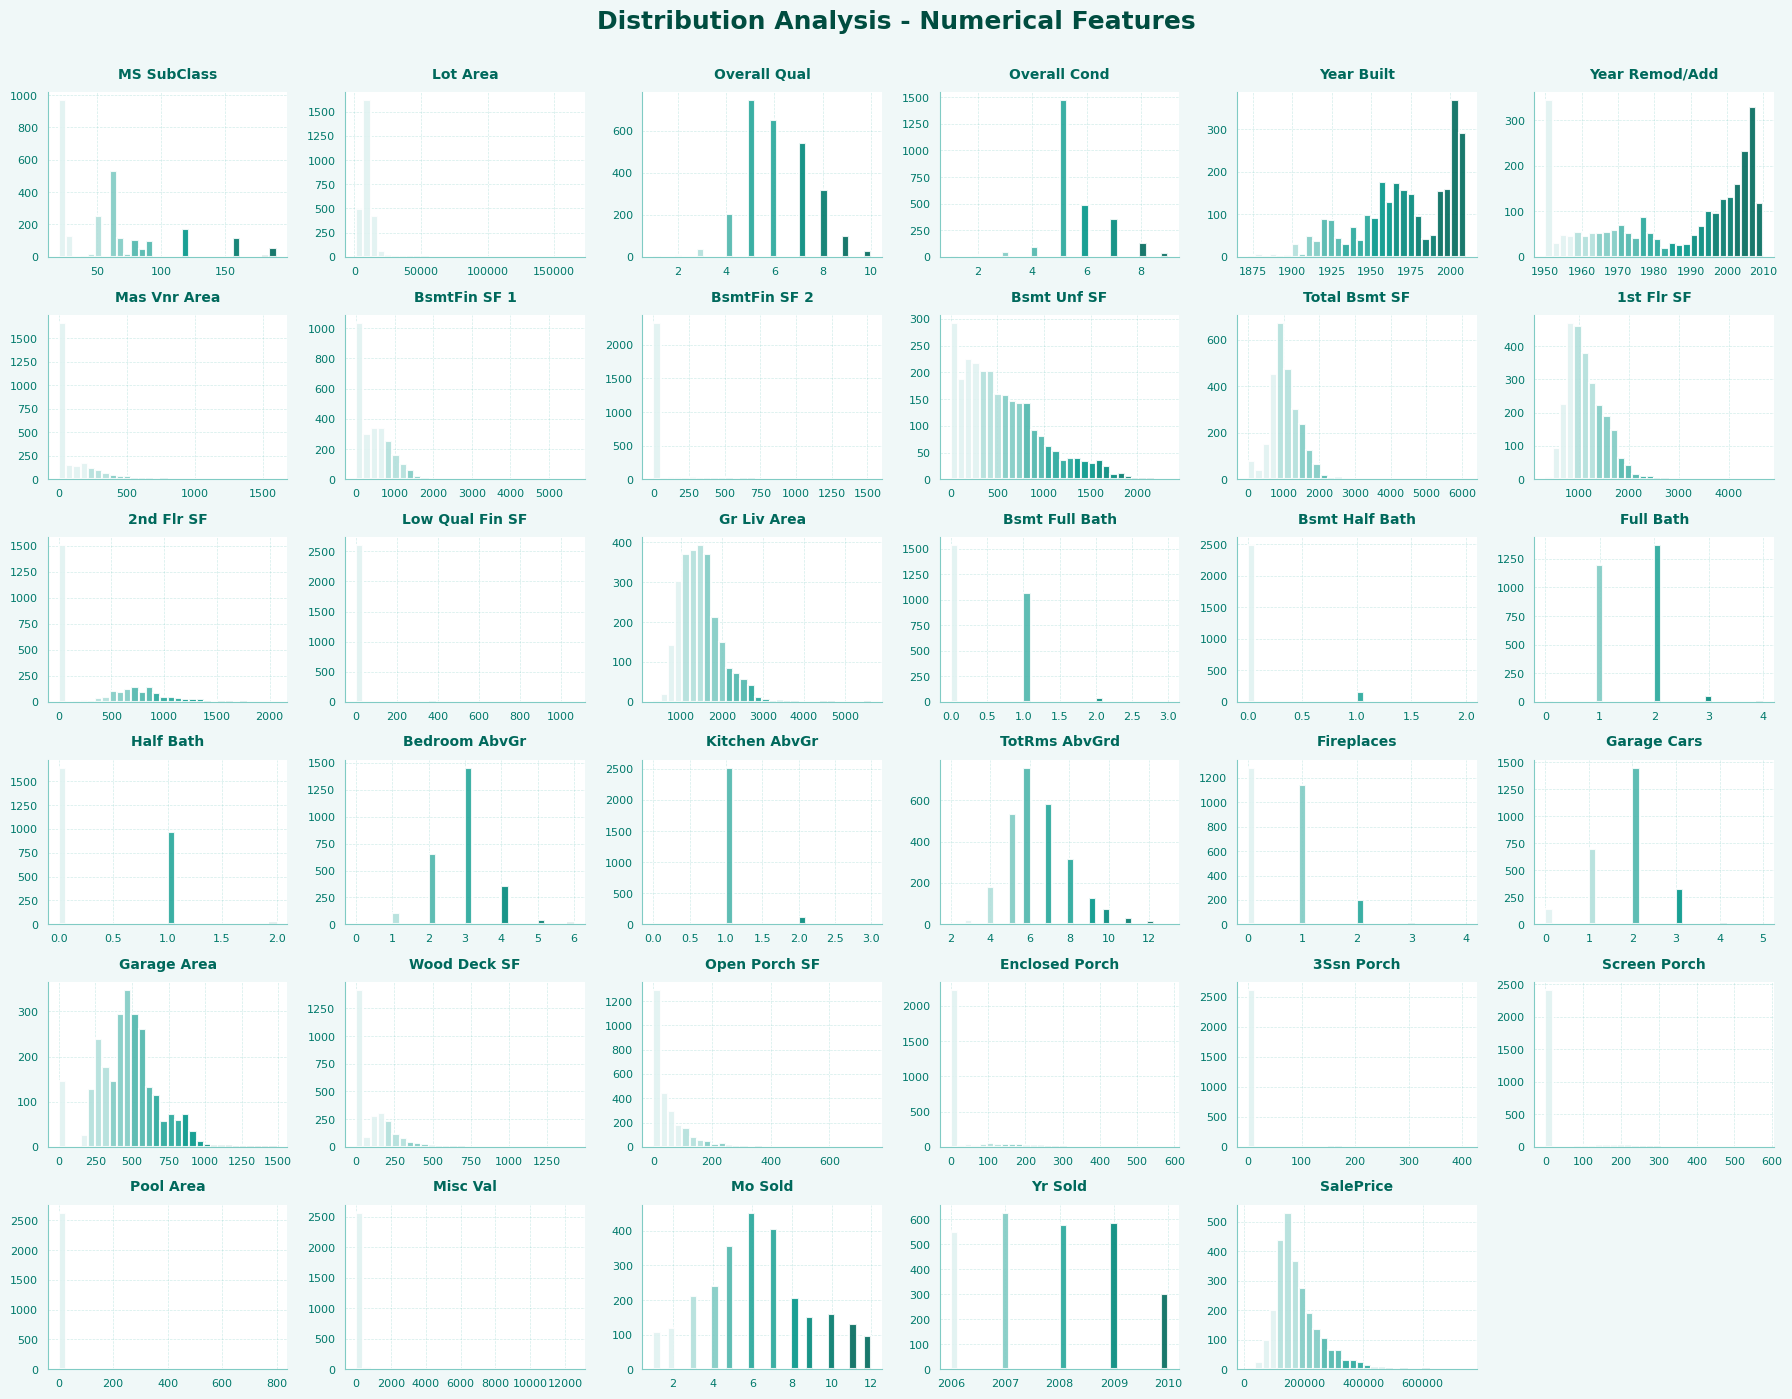

In [39]:
#Creating the Histogram
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 9

# Create figure with subplots
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#f0f8f8')

# Get numeric columns
numeric_cols = house_num_df.columns.tolist()

# Define teal color palette - gradient from light teal to deep teal
teal_colors = ['#E0F2F1', '#B2DFDB', '#80CBC4', '#4DB6AC', '#26A69A', '#009688', '#00897B', '#00796B', '#00695C', '#004D40']

# Create subplots
n_cols = 6
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

for idx, col in enumerate(numeric_cols):
    ax = plt.subplot(n_rows, n_cols, idx + 1)

    # Create histogram with teal gradient
    n, bins, patches = ax.hist(house_num_df[col].dropna(),bins=30,edgecolor='white',linewidth=1.5,alpha=0.9)

    # Apply teal gradient coloring to bars
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    col_norm = (bin_centers - bin_centers.min()) / (bin_centers.max() - bin_centers.min() + 1e-10)

    for c, p in zip(col_norm, patches):
        # Interpolate between light teal and deep teal
        color_idx = int(c * (len(teal_colors) - 1))
        plt.setp(p, 'facecolor', teal_colors[color_idx])

    # Styling
    ax.set_title(col, fontsize=10, fontweight='bold', pad=10, color='#00695C')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.5, color='#4DB6AC')
    ax.set_facecolor('#ffffff')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#80CBC4')
    ax.spines['bottom'].set_color('#80CBC4')

    # Format tick labels
    ax.tick_params(colors='#00796B', labelsize=8)

plt.suptitle('Distribution Analysis - Numerical Features', fontsize=18, fontweight='bold', y=0.995, color='#004D40')
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

* Feature Selection for Model

In [40]:
#Split into Features and Target
X = house_num_df.drop('SalePrice',axis=1)
y = house_num_df['SalePrice']

## Data Processing

###Creating the Linear Regression Model

In [41]:
#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scaling the Features
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

#Model:Linear Regression for training
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

#Creating Predictions
y_predict = linear_reg.predict(X_test)

#Calculating RMSPE
def RMSPE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square((( y_actual - y_predict ) / y_actual ))))

rmspe_result = RMSPE(y_test, y_predict)

print(f"RMSPE:{rmspe_result*100:.2f}%")
print(f"Number of Predictors: {len(X.columns)}")

RMSPE:18.56%
Number of Predictors: 34


### RMSPE Results on the model
* RMSPE gives: 18.56%
* Number of Predictors: 34

Actual vs Predicted Plot

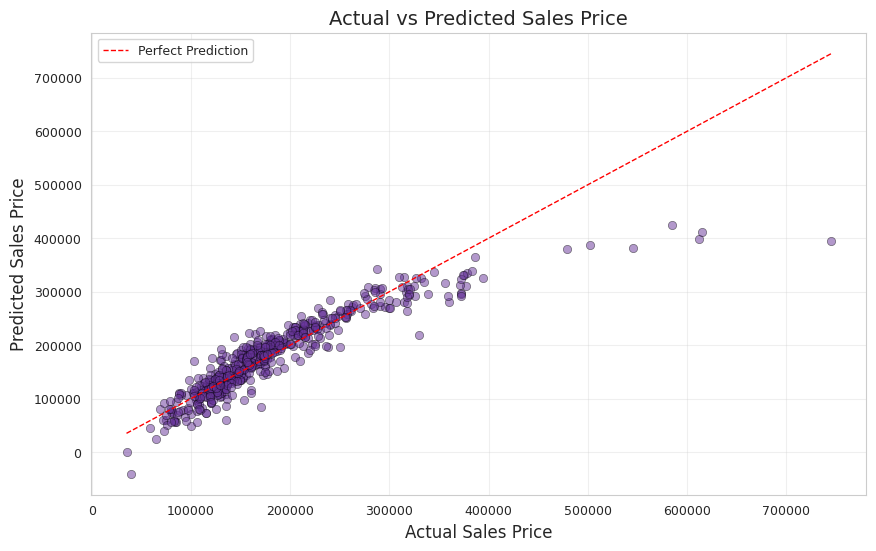

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, alpha=0.5, color='rebeccapurple',edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1, label='Perfect Prediction')
plt.xlabel('Actual Sales Price', fontsize=12)
plt.ylabel('Predicted Sales Price', fontsize=12)
plt.title('Actual vs Predicted Sales Price', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

Residuals vs. Predicted

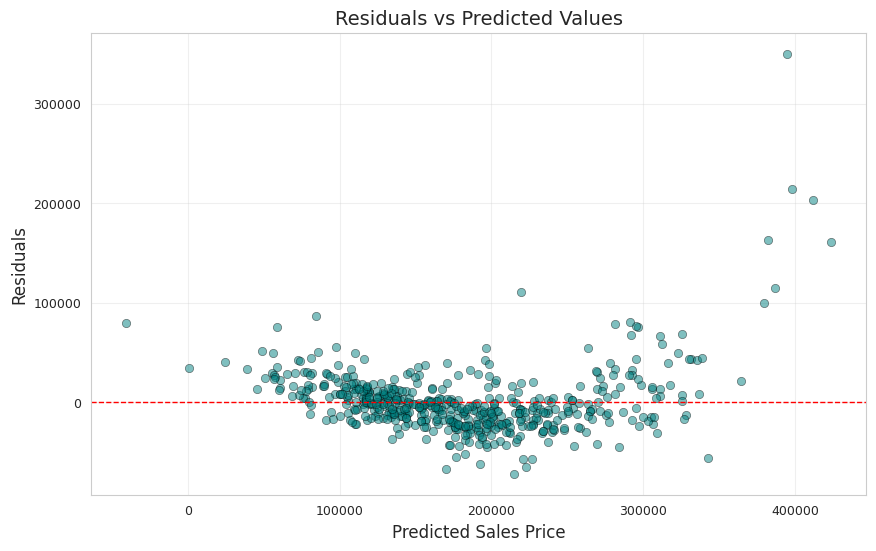

In [43]:
residuals = y_test - y_predict

plt.figure(figsize=(10, 6))
plt.scatter(y_predict, residuals, alpha=0.5, color='teal',edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.xlabel('Predicted Sales Price', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Predicted Values', fontsize=14)
plt.grid(True, alpha=0.3)

### Cross Validation

QQ Plot

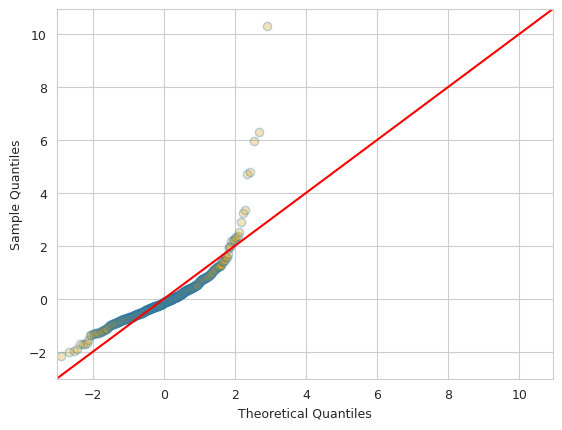

In [44]:
sm.qqplot(residuals, fit=True, line="45", alpha=0.3, markerfacecolor='goldenrod') ;

In [45]:
# Perform CV

#Function to calculate RMSPE
def RMSPE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square((( y_actual - y_predict ) / y_actual ))))

n = 500
rmspe_result = np.zeros(n)

for idx in range(n):
  #Split into training and testing sets
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

  #Model:Linear Regression for training
  linear_reg = LinearRegression()
  linear_reg.fit(X_train, y_train)

  #Creating Predictions
  y_predict = linear_reg.predict(X_test)

  #Calculating RMSPE
  rmspe_result[idx] = RMSPE(y_test, y_predict)

print(f"Mean RMSPE: {rmspe_result.mean()*100:.2f}%")
print(f"Number of Predictors: {len(X.columns)}")

Mean RMSPE: 19.61%
Number of Predictors: 34


##Data Visualization

Actual vs Predicted Plot After Cross Validation

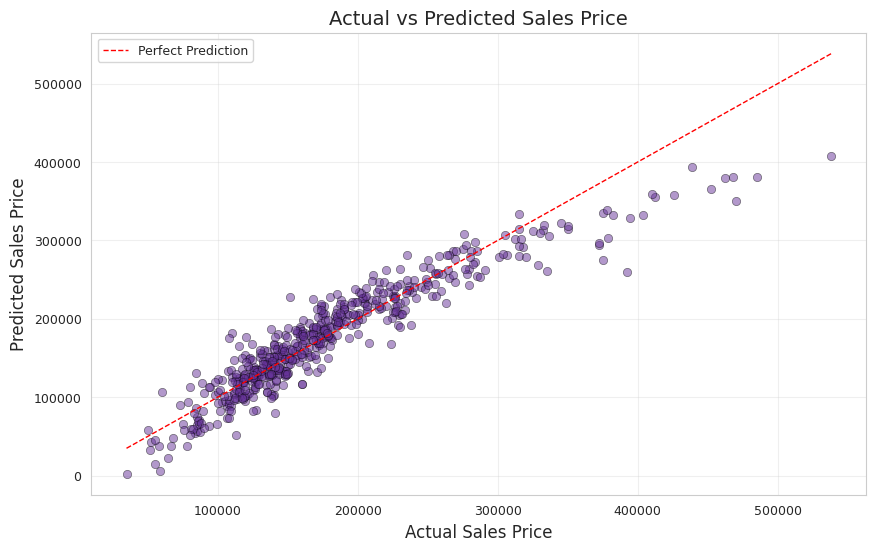

In [46]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, alpha=0.5, edgecolors='k', linewidth=0.5, color='rebeccapurple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1, label='Perfect Prediction')
plt.xlabel('Actual Sales Price', fontsize=12)
plt.ylabel('Predicted Sales Price', fontsize=12)
plt.title('Actual vs Predicted Sales Price', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

Residuals vs. Predicted

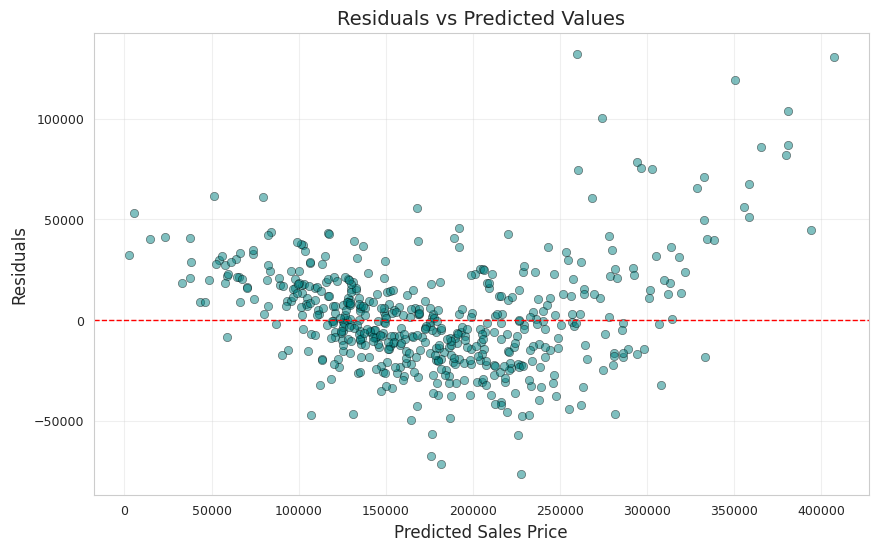

In [47]:
residuals = y_test - y_predict

plt.figure(figsize=(10, 6))
plt.scatter(y_predict, residuals, alpha=0.5, edgecolors='k', linewidth=0.5, color='teal')
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.xlabel('Predicted Sales Price', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Predicted Values', fontsize=14)
plt.grid(True, alpha=0.3)

QQ Plot

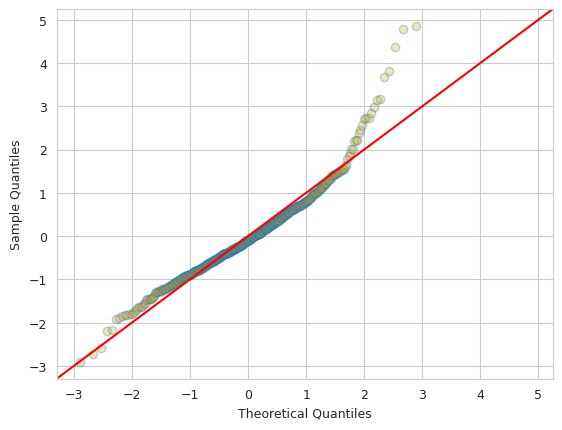

In [48]:
sm.qqplot(residuals, fit=True, line="45", alpha=0.3, markerfacecolor='goldenrod') ;

### Numerical Predictors & Numerical Response

In [49]:
#Sorting the Correlations with SalesPrice
house_num_df.corr()['SalePrice'].abs().sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
Overall Qual,0.805016
Gr Liv Area,0.705482
Garage Cars,0.647151
Garage Area,0.633877
Total Bsmt SF,0.628533
1st Flr SF,0.618247
Year Built,0.562777
Full Bath,0.542386
Year Remod/Add,0.539932


Correlation Bar Graph

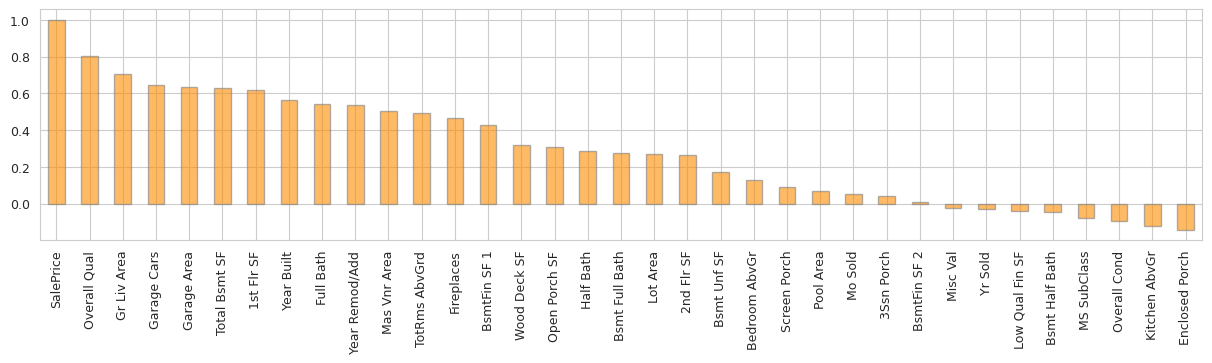

In [50]:
# Plot result
house_num_df.corr()['SalePrice'].sort_values(ascending=False).plot(kind = 'bar',color='darkorange',edgecolor='gray',
    alpha=0.6,figsize = (15,3)) ;

**Setting the Threshold to 0.6**

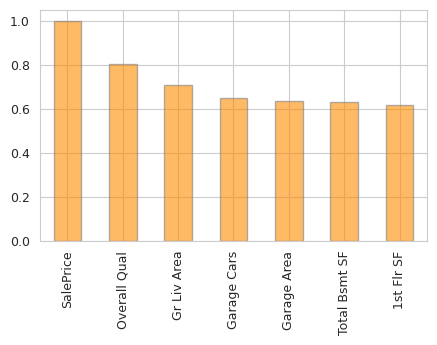

In [51]:
house_num_df.corr()['SalePrice'][house_num_df.corr()['SalePrice'].abs()>0.6].sort_values(ascending=False).plot( kind = 'bar',color='darkorange',edgecolor='gray',
    alpha=0.6,figsize = (5,3)) ;

In [52]:
#Sorting the Correlations with SalesPrice
house_num_thresh=house_num_df.corr()['SalePrice'][
    house_num_df.corr()['SalePrice'].abs()>0.6
]
house_num_thresh
# house_num_df.corr()['SalePrice'][
#     house_num_df.corr()['SalePrice'].abs()>0.6
# ].sort_values(ascending=False)

,SalePrice
Overall Qual,0.805016
Total Bsmt SF,0.628533
1st Flr SF,0.618247
Gr Liv Area,0.705482
Garage Cars,0.647151
Garage Area,0.633877
SalePrice,1.000000


In [53]:
top_6_cols = house_num_df.corr()['SalePrice'].abs().nlargest(7).index[1:].tolist()
house_num_thresh_df = house_num_df[top_6_cols + ['SalePrice']]
house_num_thresh_df

,Overall Qual,Gr Liv Area,Garage Cars,Garage Area,Total Bsmt SF,1st Flr SF,SalePrice
0,4,1005,2.0,440.0,1005.0,1005,115400
1,4,1296,2.0,516.0,0.0,1296,90000
2,6,1375,1.0,544.0,780.0,780,141000
3,8,1848,2.0,592.0,975.0,975,254000
4,7,1135,2.0,576.0,560.0,575,155000
...,...,...,...,...,...,...,...
2632,6,1176,2.0,528.0,816.0,816,114500
2633,7,1061,2.0,462.0,1054.0,1061,162000
2634,8,1226,2.0,484.0,1226.0,1226,211500
2635,6,1350,2.0,478.0,1064.0,1350,165000


**Reducing it to just 6 Features**

###Running a new Model with 0.6 Threshold and Scaling

In [54]:
#Split into Features and Target
X = house_num_thresh_df.drop('SalePrice',axis=1)
y = house_num_thresh_df['SalePrice']

In [55]:
#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scaling the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Model:Linear Regression for training
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

#Creating Predictions
y_predict = linear_reg.predict(X_test)

#Calculating RMSPE
def RMSPE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square((( y_actual - y_predict ) / y_actual ))))

rmspe_result = RMSPE(y_test, y_predict)

print(f"RMSPE:{rmspe_result*100:.2f}%")
print(f"Number of Predictors: {len(X.columns)}")

RMSPE:23.08%
Number of Predictors: 6


### RMSPE Results on the model
* RMSPE gives: 23.08%
* Number of Predictors: 6

Actual Vs Predicted on 6 features

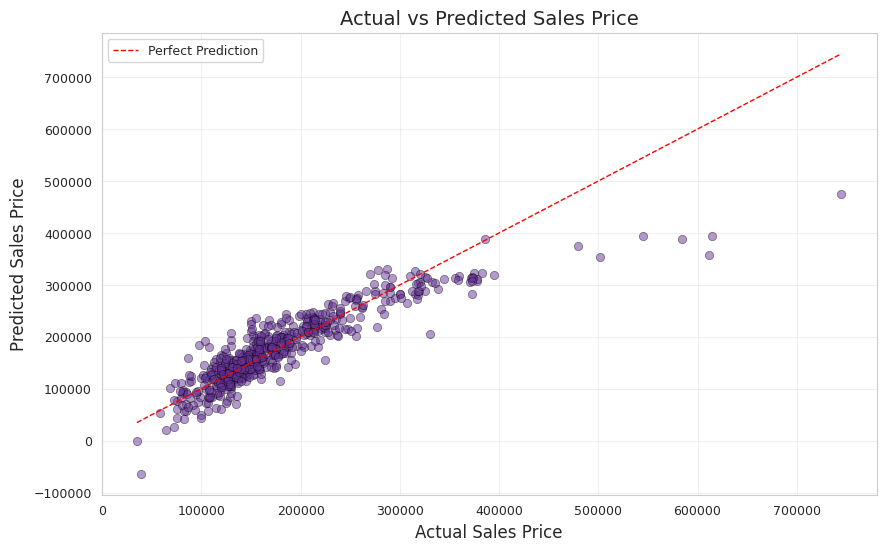

In [56]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, alpha=0.5, color='rebeccapurple', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1, label='Perfect Prediction')
plt.xlabel('Actual Sales Price', fontsize=12)
plt.ylabel('Predicted Sales Price', fontsize=12)
plt.title('Actual vs Predicted Sales Price', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

Residuals vs. Predicted

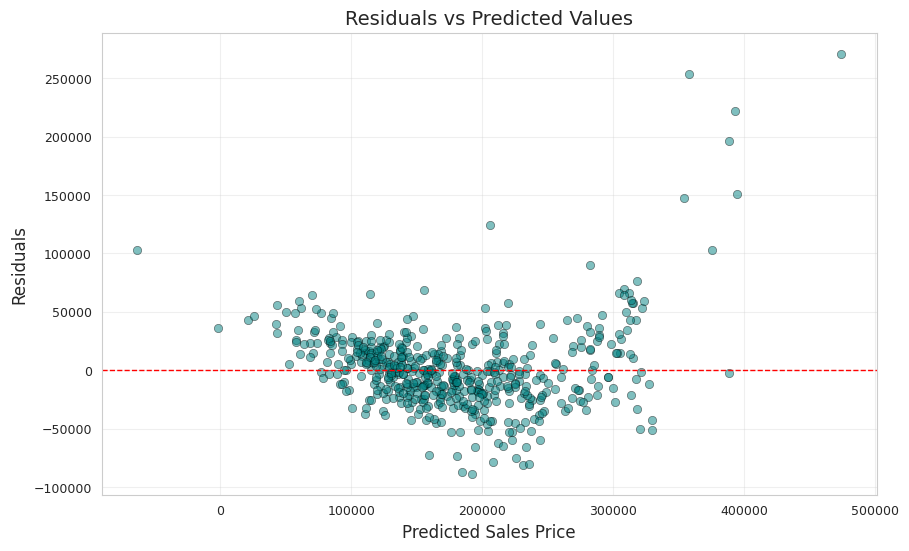

In [57]:
residuals = y_test - y_predict

plt.figure(figsize=(10, 6))
plt.scatter(y_predict, residuals, alpha=0.5, color='teal', edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.xlabel('Predicted Sales Price', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Predicted Values', fontsize=14)
plt.grid(True, alpha=0.3)

QQ Plot

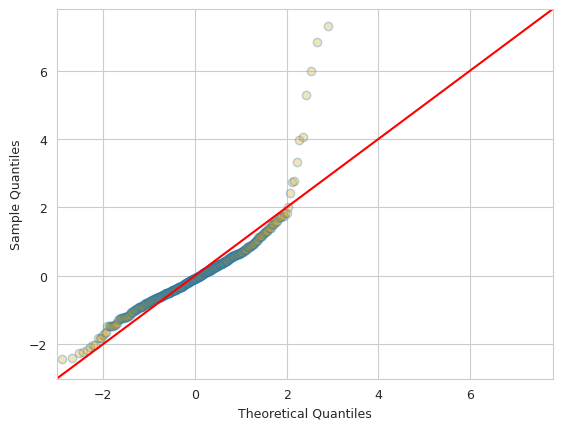

In [58]:
sm.qqplot(residuals, fit=True, line="45", alpha=0.3, markerfacecolor='goldenrod') ;

### Cross Validation

In [59]:
# Perform CV

#Function to calculate RMSPE
def RMSPE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square((( y_actual - y_predict ) / y_actual ))))

n = 500
rmspe_result = np.zeros(n)

for idx in range(n):
  #Split into training and testing sets
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

  #Model:Linear Regression for training
  linear_reg = LinearRegression()
  linear_reg.fit(X_train, y_train)

  #Creating Predictions
  y_predict = linear_reg.predict(X_test)

  #Calculating RMSPE
  rmspe_result[idx] = RMSPE(y_test, y_predict)

print(f"Mean RMSPE: {rmspe_result.mean()*100:.2f}%")
print(f"Number of Predictors: {len(X.columns)}")

Mean RMSPE: 24.09%
Number of Predictors: 6


CV Actual vs Precticted

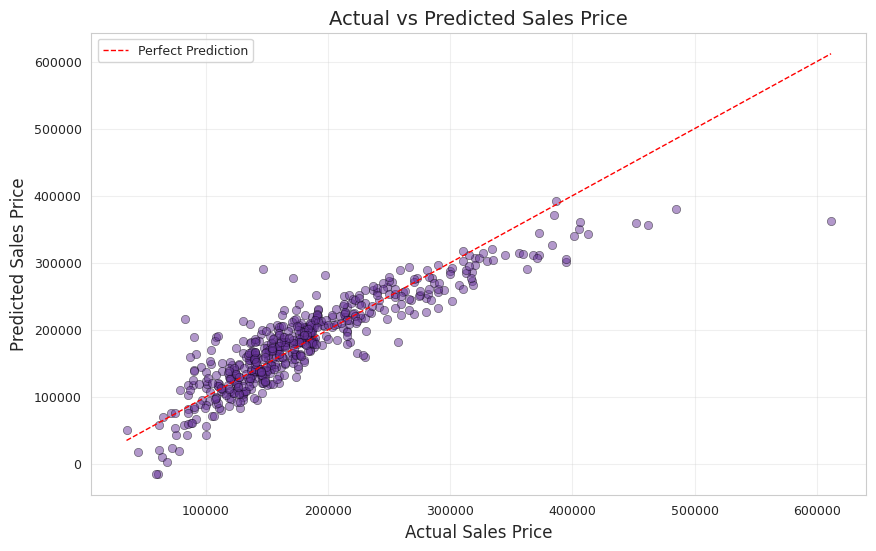

In [60]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, alpha=0.5, color='rebeccapurple', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1, label='Perfect Prediction')
plt.xlabel('Actual Sales Price', fontsize=12)
plt.ylabel('Predicted Sales Price', fontsize=12)
plt.title('Actual vs Predicted Sales Price', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

Residual vs Predicted

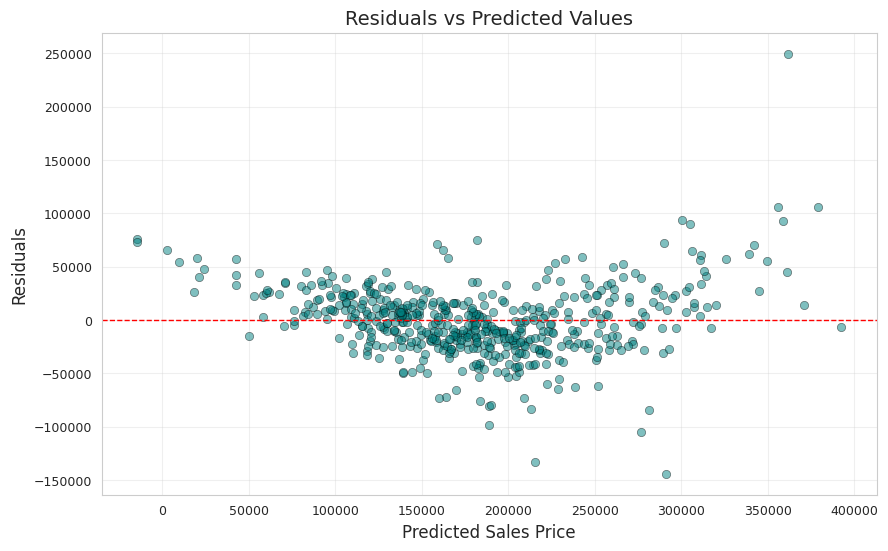

In [61]:
residuals = y_test - y_predict

plt.figure(figsize=(10, 6))
plt.scatter(y_predict, residuals,alpha=0.5, color='teal', edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.xlabel('Predicted Sales Price', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Predicted Values', fontsize=14)
plt.grid(True, alpha=0.3)

QQ Plot

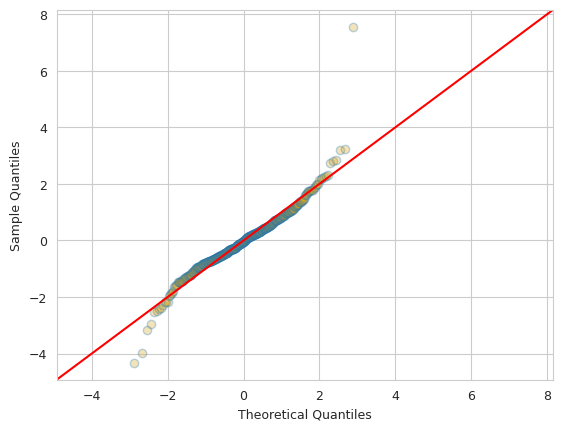

In [62]:
sm.qqplot(residuals, fit=True, line="45", alpha=0.3, markerfacecolor='goldenrod') ;

###Running a Ridge Regression model

In [63]:
#Split into Features and Target
X = house_num_thresh_df.drop('SalePrice',axis=1)
y = house_num_thresh_df['SalePrice']

In [64]:
#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scaling the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Regularization with Ridge Regression
ridge = Ridge(alpha=1.0)  # Adjust alpha for regularization strength
ridge.fit(X_train, y_train)

#Creating Predictions
y_predict = ridge.predict(X_test)

#Calculating RMSPE
def RMSPE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square((( y_actual - y_predict ) / y_actual ))))

rmspe_result = RMSPE(y_test, y_predict)

print(f"RMSPE:{rmspe_result*100:.2f}%")
print(f"Number of Predictors: {len(X.columns)}")

RMSPE:23.07%
Number of Predictors: 6


Ridge Regression: Actual vs Precticted

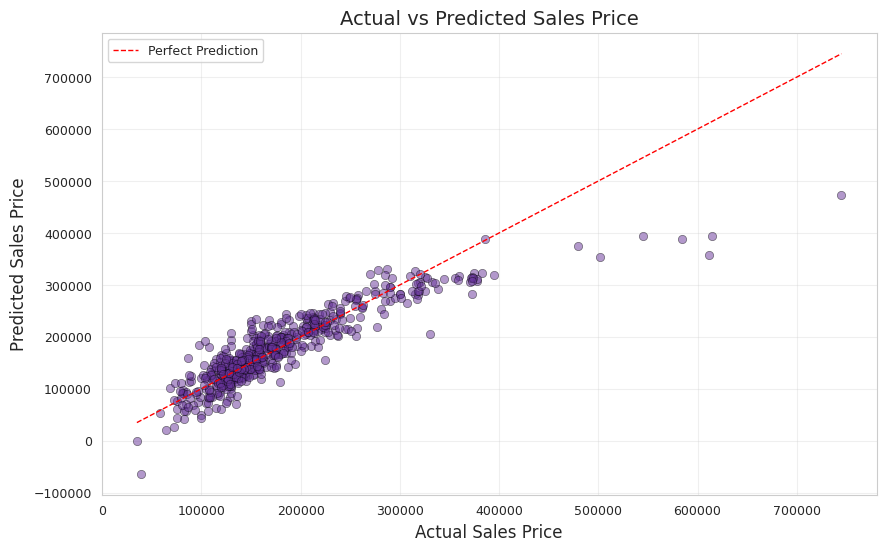

In [65]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, alpha=0.5, color='rebeccapurple', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1, label='Perfect Prediction')
plt.xlabel('Actual Sales Price', fontsize=12)
plt.ylabel('Predicted Sales Price', fontsize=12)
plt.title('Actual vs Predicted Sales Price', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

Ridge Regression: Residual vs Predicted

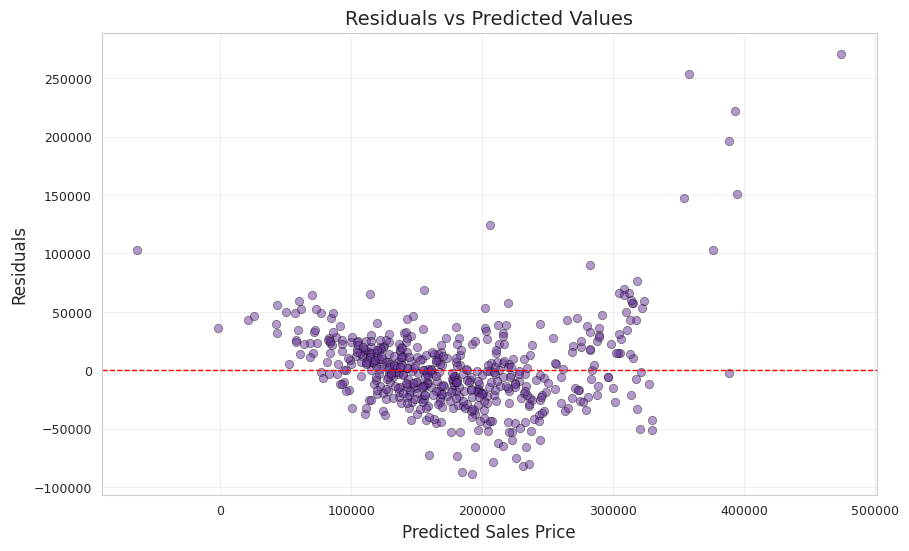

In [66]:
residuals = y_test - y_predict

plt.figure(figsize=(10, 6))
plt.scatter(y_predict, residuals, alpha=0.5, color='rebeccapurple', edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.xlabel('Predicted Sales Price', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Predicted Values', fontsize=14)
plt.grid(True, alpha=0.3)

###Running a Lasso Regression model

In [67]:
X_lasso = house_num_thresh_df.drop('SalePrice',axis=1)
y_lasso = house_num_thresh_df['SalePrice']

#Calculating RMSPE
def RMSPE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square((( y_actual - y_predict ) / y_actual ))))

# Specify values of alpha we want to try
alph = [50, 75, 100, 200, 300, ]

# Create empty list to hold results
results_alpha = []

for i in alph:
  # Calculate CV RMSE
  n = 200
  results = np.zeros(n)

  for idx in range(n):
    # Create the model
    my_fit_lasso = Lasso(alpha = i, tol = .01, max_iter=10_000); # Looping through alpha

    # Train, test split
    X_train, X_test, y_train, y_test = train_test_split(X_lasso, y_lasso, test_size=0.25)

    # Standard scale only training features
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)

    # Scale testing features
    X_test = scaler.transform(X_test)

    # Fit regression
    my_fit_lasso.fit(X_train, y_train)

    # Predict
    y_pred = my_fit_lasso.predict(X_test)

    # Calculate and record performance metric
    results[idx] = RMSPE(y_test, y_pred)

  results_alpha.append(results.mean()*100)

results_df = pd.DataFrame({'Alpha': alph, 'RMSPE': results_alpha})

results_df.sort_values( by = 'RMSPE' )

,Alpha,RMSPE
0,50,24.115502
4,300,24.192989
2,100,24.382356
1,75,24.387125
3,200,24.431025


Alpha = 300 Since RMSPE is the lowest on this Alpha

In [68]:
alpha=results_df.sort_values( by = 'RMSPE')["Alpha"][0]
alpha

np.int64(50)

In [69]:
# Perform CV
n = 500
results = np.zeros(n)

#Calculating RMSPE
def RMSPE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square((( y_actual - y_predict ) / y_actual ))))


for idx in range(n):
  # Train, test split
  X_train, X_test, y_train, y_test = train_test_split(X_lasso, y_lasso, test_size=0.25)

  # Standard scale only training features
  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train = scaler.transform(X_train)

  # Scale testing features
  X_test = scaler.transform(X_test)

  # Create the model
  model = Lasso(alpha = alpha, tol = .01, max_iter=10000)

  # Fit regression
  model.fit(X_train, y_train)

  # Predict
  y_pred = model.predict(X_test)

  # Calculate and record performance metric
  results[idx] = RMSPE(y_test, y_pred)

print(f"CV RMSPE: {results.mean()*100:.2f}%")
print(f"Number of Predictors: {len(X.columns)}")

CV RMSPE: 24.26%
Number of Predictors: 6


Lasso Regression: Actual vs Precticted

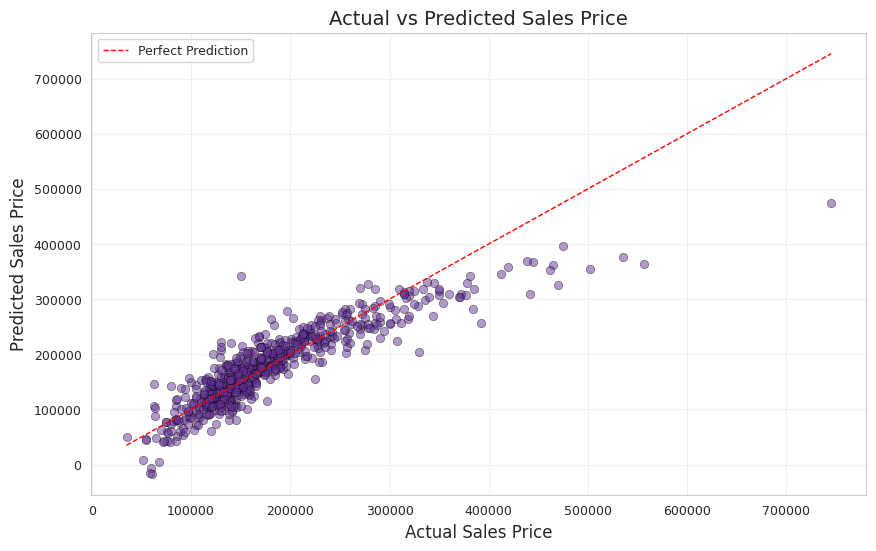

In [70]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='rebeccapurple', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1, label='Perfect Prediction')
plt.xlabel('Actual Sales Price', fontsize=12)
plt.ylabel('Predicted Sales Price', fontsize=12)
plt.title('Actual vs Predicted Sales Price', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)